# Fatigue Behavioral Clean Rerun Notebook

This notebook reconstructs the behavioral driver drowsiness experiment from `eye_features.csv` using the real driver identifiers embedded in the image filenames. It is designed to produce a clean, defensible experimental foundation for the journal manuscript.

**Main goals**

1. Load and audit the processed EAR feature dataset.
2. Extract real driver IDs from filenames.
3. Generate temporal EAR-based features.
4. Build sequences without crossing driver/scenario boundaries.
5. Evaluate classical and temporal models under Leave-One-Driver-Out validation.
6. Save all tables and figures for manuscript use.

## 1. Imports and configuration

In [6]:
import os
import re
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

DATA_PATH = Path("eye_features.csv")  # Put this notebook in the same folder as eye_features.csv
OUT_DIR = Path("results_clean")
OUT_DIR.mkdir(exist_ok=True)

SEQ_LENS = [10, 20, 30]
EAR_THRESHOLD = 0.21
ROLLING_WINDOW = 5

print("Ready. Output folder:", OUT_DIR.resolve())

Ready. Output folder: C:\Users\LATITUDE E7470\Desktop\ajcodes\research\fatigueanalysis1\results_clean


## 2. Load the processed EAR dataset

In [7]:
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())
print("\nLabel distribution:")
print(df["label"].value_counts().sort_index())

Dataset shape: (65929, 3)
Columns: ['image_name', 'ear', 'label']
                                      image_name       ear  label
0  001_glasses_sleepyCombination_1000_drowsy.jpg  0.284489      1
1  001_glasses_sleepyCombination_1001_drowsy.jpg  0.297797      1
2  001_glasses_sleepyCombination_1002_drowsy.jpg  0.298301      1
3  001_glasses_sleepyCombination_1003_drowsy.jpg  0.288216      1
4  001_glasses_sleepyCombination_1004_drowsy.jpg  0.281307      1

Label distribution:
label
0    29906
1    36023
Name: count, dtype: int64


## 3. Extract subject, stream, and frame information

The filename pattern contains the real driver identifier at the beginning of each image filename, for example `001_glasses_sleepyCombination_1000_drowsy.jpg`. This notebook uses the first three digits as the actual driver/subject group. The stream identifier prevents sequence windows from crossing between different driver-scenario segments.

In [8]:
def parse_filename(name: str):
    stem = Path(str(name)).stem
    # Driver ID is the first 3 digits before the first underscore
    m_subject = re.match(r"^(\d{3})_", stem)
    subject_id = m_subject.group(1) if m_subject else "unknown"

    # Frame number is the last numeric token before the label token
    tokens = stem.split("_")
    frame_no = None
    for tok in reversed(tokens):
        if tok.isdigit():
            frame_no = int(tok)
            break

    # Remove trailing frame number and label token to create a stream id
    # Example: 001_glasses_sleepyCombination_1000_drowsy -> 001_glasses_sleepyCombination
    stream = re.sub(r"_\d+_(drowsy|notDrowsy|not_drowsy|alert|nonDrowsy|non_drowsy)$", "", stem, flags=re.IGNORECASE)
    return subject_id, stream, frame_no

parsed = df["image_name"].apply(parse_filename)
df["subject_id"] = parsed.apply(lambda x: x[0])
df["stream_id"] = parsed.apply(lambda x: x[1])
df["frame_no"] = parsed.apply(lambda x: x[2])

# Sort by stream and frame number to preserve temporal ordering
df = df.sort_values(["subject_id", "stream_id", "frame_no", "image_name"]).reset_index(drop=True)

print("Unique subjects:", sorted(df["subject_id"].unique()))
print("Number of streams:", df["stream_id"].nunique())
print("\nSamples per subject and class:")
print(pd.crosstab(df["subject_id"], df["label"]))
print("\nExample parsed rows:")
print(df[["image_name", "subject_id", "stream_id", "frame_no", "ear", "label"]].head(10))

Unique subjects: ['001', '002', '005', '006']
Number of streams: 27

Samples per subject and class:
label          0      1
subject_id             
001         9336   9578
002         7829  10595
005         8843  13087
006         3898   2763

Example parsed rows:
                                         image_name subject_id  \
0  001_glasses_nonsleepyCombination_0_notdrowsy.jpg        001   
1  001_glasses_nonsleepyCombination_1_notdrowsy.jpg        001   
2  001_glasses_nonsleepyCombination_2_notdrowsy.jpg        001   
3  001_glasses_nonsleepyCombination_3_notdrowsy.jpg        001   
4  001_glasses_nonsleepyCombination_4_notdrowsy.jpg        001   
5  001_glasses_nonsleepyCombination_5_notdrowsy.jpg        001   
6  001_glasses_nonsleepyCombination_6_notdrowsy.jpg        001   
7  001_glasses_nonsleepyCombination_7_notdrowsy.jpg        001   
8  001_glasses_nonsleepyCombination_8_notdrowsy.jpg        001   
9  001_glasses_nonsleepyCombination_9_notdrowsy.jpg        001   

       

## 4. Feature engineering

Features are generated within each stream to avoid leakage across different driver-scenario segments. The four core features reproduce the original behavioral model: raw EAR, rolling mean EAR, frame-to-frame EAR change, and binary eye-closure flag.

In [9]:
def add_temporal_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()
    out["ear_rolling_mean"] = out.groupby("stream_id")["ear"].transform(
        lambda s: s.rolling(window=ROLLING_WINDOW, min_periods=1).mean()
    )
    out["ear_delta"] = out.groupby("stream_id")["ear"].diff().fillna(0)
    out["eye_closed"] = (out["ear"] < EAR_THRESHOLD).astype(int)
    return out

df = add_temporal_features(df)
FEATURE_COLS = ["ear", "ear_rolling_mean", "ear_delta", "eye_closed"]
print(df[FEATURE_COLS + ["label", "subject_id", "stream_id"]].head())
print("\nFeature summary:")
print(df[FEATURE_COLS].describe())

        ear  ear_rolling_mean  ear_delta  eye_closed  label subject_id  \
0  0.287188          0.287188   0.000000           0      0        001   
1  0.297649          0.292418   0.010461           0      0        001   
2  0.286146          0.290327  -0.011503           0      0        001   
3  0.293520          0.291126   0.007374           0      0        001   
4  0.290787          0.291058  -0.002733           0      0        001   

                          stream_id  
0  001_glasses_nonsleepyCombination  
1  001_glasses_nonsleepyCombination  
2  001_glasses_nonsleepyCombination  
3  001_glasses_nonsleepyCombination  
4  001_glasses_nonsleepyCombination  

Feature summary:
                ear  ear_rolling_mean     ear_delta    eye_closed
count  65929.000000      65929.000000  65929.000000  65929.000000
mean       0.264725          0.264729     -0.000001      0.095011
std        0.048999          0.047643      0.014940      0.293233
min        0.029880          0.057453     -0.

## 5. Sequence generation without stream crossing

Each sequence is created inside a single stream only. The sequence label is taken from the final frame in the temporal window, matching the original implementation logic.

In [10]:
def make_sequences(data: pd.DataFrame, seq_len: int, feature_cols=FEATURE_COLS):
    X, y, groups, stream_ids = [], [], [], []
    for stream_id, g in data.groupby("stream_id", sort=False):
        g = g.sort_values("frame_no")
        feats = g[feature_cols].values.astype("float32")
        labels = g["label"].values.astype("int32")
        subject = g["subject_id"].iloc[0]
        if len(g) < seq_len:
            continue
        for i in range(len(g) - seq_len + 1):
            X.append(feats[i:i+seq_len])
            y.append(labels[i+seq_len-1])
            groups.append(subject)
            stream_ids.append(stream_id)
    return np.array(X), np.array(y), np.array(groups), np.array(stream_ids)

for L in SEQ_LENS:
    X_tmp, y_tmp, groups_tmp, streams_tmp = make_sequences(df, L)
    print(f"SEQ_LEN={L}: X={X_tmp.shape}, y distribution={dict(zip(*np.unique(y_tmp, return_counts=True)))}, subjects={sorted(np.unique(groups_tmp))}")

SEQ_LEN=10: X=(65686, 10, 4), y distribution={0: 29663, 1: 36023}, subjects=['001', '002', '005', '006']
SEQ_LEN=20: X=(65416, 20, 4), y distribution={0: 29393, 1: 36023}, subjects=['001', '002', '005', '006']
SEQ_LEN=30: X=(65146, 30, 4), y distribution={0: 29123, 1: 36023}, subjects=['001', '002', '005', '006']


## 6. Helper functions for evaluation and plotting

In [11]:
def safe_auc(y_true, y_score):
    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan

def safe_auprc(y_true, y_score):
    try:
        return average_precision_score(y_true, y_score)
    except Exception:
        return np.nan

def compute_metrics(y_true, y_pred, y_score=None):
    if y_score is None:
        y_score = y_pred
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_drowsy": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_drowsy": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_drowsy": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "auroc": safe_auc(y_true, y_score),
        "auprc": safe_auprc(y_true, y_score),
    }

def flatten_sequences(X):
    return X.reshape(X.shape[0], -1)

def save_confusion_matrix(cm, title, path):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Not drowsy", "Drowsy"])
    ax.set_yticklabels(["Not drowsy", "Drowsy"])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## 7. Leave-One-Driver-Out evaluation for classical baselines

This is the strongest validation protocol available from the current dataset because it tests each real driver as an unseen subject.

In [12]:
all_results = []
all_predictions = []

for seq_len in SEQ_LENS:
    X, y, groups, stream_ids = make_sequences(df, seq_len)
    subjects = sorted(np.unique(groups))
    print("\n=== Sequence length", seq_len, "===")
    for test_subject in subjects:
        train_idx = groups != test_subject
        test_idx = groups == test_subject
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Scale flattened features using training data only
        scaler = MinMaxScaler()
        X_train_flat = scaler.fit_transform(flatten_sequences(X_train))
        X_test_flat = scaler.transform(flatten_sequences(X_test))

        models = {
            "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
            "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1),
        }

        for model_name, clf in models.items():
            clf.fit(X_train_flat, y_train)
            y_pred = clf.predict(X_test_flat)
            if hasattr(clf, "predict_proba"):
                y_score = clf.predict_proba(X_test_flat)[:, 1]
            else:
                y_score = y_pred
            row = {
                "seq_len": seq_len,
                "model": model_name,
                "test_subject": test_subject,
                "n_train": len(y_train),
                "n_test": len(y_test),
            }
            row.update(compute_metrics(y_test, y_pred, y_score))
            all_results.append(row)
            for yt, yp, ys in zip(y_test, y_pred, y_score):
                all_predictions.append({"seq_len": seq_len, "model": model_name, "test_subject": test_subject, "y_true": int(yt), "y_pred": int(yp), "y_score": float(ys)})
            print(model_name, "test subject", test_subject, "accuracy", round(row["accuracy"], 4), "f1_drowsy", round(row["f1_drowsy"], 4))

results_df = pd.DataFrame(all_results)
preds_df = pd.DataFrame(all_predictions)
results_df.to_csv(OUT_DIR / "classical_lodo_fold_results.csv", index=False)
preds_df.to_csv(OUT_DIR / "classical_lodo_predictions.csv", index=False)

summary_classical = (
    results_df
    .groupby(["seq_len","model"])[
        ["accuracy","precision","recall","f1_drowsy"]
    ]
    .agg(["mean","std"])
    .round(4)
)


=== Sequence length 10 ===
LogisticRegression test subject 001 accuracy 0.5552 f1_drowsy 0.4717
RandomForest test subject 001 accuracy 0.5381 f1_drowsy 0.5965
LogisticRegression test subject 002 accuracy 0.5043 f1_drowsy 0.565
RandomForest test subject 002 accuracy 0.5178 f1_drowsy 0.5633
LogisticRegression test subject 005 accuracy 0.5675 f1_drowsy 0.5749
RandomForest test subject 005 accuracy 0.5327 f1_drowsy 0.5898
LogisticRegression test subject 006 accuracy 0.6756 f1_drowsy 0.7047
RandomForest test subject 006 accuracy 0.5577 f1_drowsy 0.6352

=== Sequence length 20 ===
LogisticRegression test subject 001 accuracy 0.5515 f1_drowsy 0.4647
RandomForest test subject 001 accuracy 0.5546 f1_drowsy 0.6138
LogisticRegression test subject 002 accuracy 0.4966 f1_drowsy 0.5569
RandomForest test subject 002 accuracy 0.5328 f1_drowsy 0.5762
LogisticRegression test subject 005 accuracy 0.5715 f1_drowsy 0.5812
RandomForest test subject 005 accuracy 0.548 f1_drowsy 0.6062
LogisticRegression tes

KeyError: "Columns not found: 'recall', 'precision'"

## 8. Optional TensorFlow deep models: LSTM and BiLSTM

Run this section only if TensorFlow is available on your Anaconda environment. It evaluates LSTM and BiLSTM under the same Leave-One-Driver-Out protocol. This section may take longer than the classical baselines.

In [13]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.optimizers import Adam
    TF_AVAILABLE = True
    tf.random.set_seed(SEED)
    print("TensorFlow version:", tf.__version__)
except Exception as e:
    TF_AVAILABLE = False
    print("TensorFlow not available:", e)

def build_lstm(seq_len, n_features, bidirectional=False):
    model = Sequential()
    model.add(Input(shape=(seq_len, n_features)))
    if bidirectional:
        model.add(Bidirectional(LSTM(64, return_sequences=False)))
    else:
        model.add(LSTM(64, return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation="relu"))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(loss="binary_crossentropy", optimizer=Adam(learning_rate=1e-3), metrics=["accuracy"])
    return model

TensorFlow version: 2.19.0


In [14]:
deep_results = []
deep_predictions = []

if TF_AVAILABLE:
    for seq_len in SEQ_LENS:
        X, y, groups, stream_ids = make_sequences(df, seq_len)
        subjects = sorted(np.unique(groups))
        print("\n=== Deep models, sequence length", seq_len, "===")
        for test_subject in subjects:
            train_idx = groups != test_subject
            test_idx = groups == test_subject
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            # Scale feature columns using training data only; preserve 3D shape
            scaler = MinMaxScaler()
            X_train_flat = scaler.fit_transform(flatten_sequences(X_train))
            X_test_flat = scaler.transform(flatten_sequences(X_test))
            X_train_s = X_train_flat.reshape(X_train.shape)
            X_test_s = X_test_flat.reshape(X_test.shape)

            for model_name, bidir in [("LSTM", False), ("BiLSTM", True)]:
                tf.keras.backend.clear_session()
                model = build_lstm(seq_len, X.shape[2], bidirectional=bidir)
                cb = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
                history = model.fit(
                    X_train_s, y_train,
                    validation_split=0.15,
                    epochs=30,
                    batch_size=64,
                    verbose=0,
                    callbacks=[cb]
                )
                y_score = model.predict(X_test_s, verbose=0).ravel()
                y_pred = (y_score >= 0.5).astype(int)
                row = {
                    "seq_len": seq_len,
                    "model": model_name,
                    "test_subject": test_subject,
                    "n_train": len(y_train),
                    "n_test": len(y_test),
                    "epochs_run": len(history.history["loss"]),
                }
                row.update(compute_metrics(y_test, y_pred, y_score))
                deep_results.append(row)
                for yt, yp, ys in zip(y_test, y_pred, y_score):
                    deep_predictions.append({"seq_len": seq_len, "model": model_name, "test_subject": test_subject, "y_true": int(yt), "y_pred": int(yp), "y_score": float(ys)})
                print(model_name, "test subject", test_subject, "accuracy", round(row["accuracy"], 4), "f1_drowsy", round(row["f1_drowsy"], 4), "epochs", row["epochs_run"])

    deep_results_df = pd.DataFrame(deep_results)
    deep_preds_df = pd.DataFrame(deep_predictions)
    deep_results_df.to_csv(OUT_DIR / "deep_lodo_fold_results.csv", index=False)
    deep_preds_df.to_csv(OUT_DIR / "deep_lodo_predictions.csv", index=False)
    summary_deep = deep_results_df.groupby(["seq_len", "model"]).agg(['mean', 'std'])
    summary_deep.to_csv(OUT_DIR / "deep_lodo_summary_mean_std.csv")
    display(summary_deep)
else:
    print("Skipping deep models because TensorFlow is not available.")


=== Deep models, sequence length 10 ===

LSTM test subject 001 accuracy 0.5205 f1_drowsy 0.5919 epochs 6
BiLSTM test subject 001 accuracy 0.5212 f1_drowsy 0.5912 epochs 13
LSTM test subject 002 accuracy 0.5028 f1_drowsy 0.5955 epochs 13
BiLSTM test subject 002 accuracy 0.5032 f1_drowsy 0.5942 epochs 27
LSTM test subject 005 accuracy 0.5511 f1_drowsy 0.647 epochs 14
BiLSTM test subject 005 accuracy 0.5362 f1_drowsy 0.6529 epochs 15
LSTM test subject 006 accuracy 0.4457 f1_drowsy 0.6005 epochs 11
BiLSTM test subject 006 accuracy 0.4709 f1_drowsy 0.6029 epochs 24

=== Deep models, sequence length 20 ===
LSTM test subject 001 accuracy 0.5432 f1_drowsy 0.6374 epochs 9
BiLSTM test subject 001 accuracy 0.5447 f1_drowsy 0.6459 epochs 6
LSTM test subject 002 accuracy 0.4982 f1_drowsy 0.5708 epochs 11
BiLSTM test subject 002 accuracy 0.4944 f1_drowsy 0.5592 epochs 8
LSTM test subject 005 accuracy 0.5315 f1_drowsy 0.5279 epochs 6
BiLSTM test subject 005 accuracy 0.5325 f1_drowsy 0.5592 epochs 20

TypeError: agg function failed [how->mean,dtype->object]

## 9. Combine and summarize all results

In [15]:
frames = []
if 'results_df' in globals() and len(results_df):
    frames.append(results_df)
if 'deep_results_df' in globals() and len(deep_results_df):
    frames.append(deep_results_df)

all_fold_results = pd.concat(frames, ignore_index=True)
all_fold_results.to_csv(OUT_DIR / "all_lodo_fold_results.csv", index=False)

metrics = ["accuracy", "precision_drowsy", "recall_drowsy", "f1_drowsy", "macro_f1", "weighted_f1", "auroc", "auprc"]
summary = all_fold_results.groupby(["seq_len", "model"])[metrics].agg(["mean", "std"]).reset_index()
summary.to_csv(OUT_DIR / "summary_results.csv", index=False)
summary

seq_len               model  accuracy           precision_drowsy            \
                                    mean       std             mean       std   
0       10              BiLSTM  0.507869  0.028107         0.528629  0.066434   
1       10                LSTM  0.505051  0.044297         0.530875  0.077181   
2       10  LogisticRegression  0.575659  0.072034         0.608467  0.061242   
3       10        RandomForest  0.536554  0.016523         0.557996  0.060671   
4       20              BiLSTM  0.510367  0.034462         0.546627  0.084571   
5       20                LSTM  0.513120  0.029374         0.553898  0.092655   
6       20  LogisticRegression  0.573670  0.074638         0.608850  0.064823   
7       20        RandomForest  0.549320  0.012340         0.570575  0.065760   
8       30              BiLSTM  0.539674  0.042761         0.562696  0.078786   
9       30                LSTM  0.545301  0.037936         0.575715  0.071149   
10      30  LogisticRegression  0.573514  0.075972         0.611619  0.071459   
11      30        RandomForest  0.555668  0.011837         0.576820  0.068844   

   recall_drowsy           f1_drowsy            macro_f1            \
            mean       std      mean       std      mean       std   
0       0.751035  0.147877  0.610305  0.028799  0.466470  0.043220   
1       0.751254  0.167616  0.608715  0.025797  0.460995  0.077262   
2       0.591532  0.235455  0.579082  0.095810  0.569519  0.075034   
3       0.674000  0.176746  0.596196  0.029685  0.525224  0.010167   
4       0.711603  0.229851  0.593312  0.042178  0.477852  0.059667   
5       0.693022  0.236499  0.586615  0.047740  0.484630  0.051348   
6       0.589408  0.241019  0.577390  0.099791  0.567245  0.077512   
7       0.688155  0.174609  0.609160  0.026408  0.537384  0.006806   
8       0.734819  0.230195  0.616376  0.066787  0.512574  0.042524   
9       0.660469  0.225357  0.592909  0.064000  0.535128  0.031263   
10      0.591126  0.247203  0.578387  0.101933  0.566797  0.078248   
11      0.700778  0.172876  0.618122  0.024835  0.542214  0.009508   

   weighted_f1               auroc               auprc            
          mean       std      mean       std      mean       std  
0     0.471771  0.066848  0.581869  0.121660  0.589692  0.041611  
1     0.461960  0.106032  0.609283  0.131188  0.616051  0.026547  
2     0.570969  0.069141  0.633478  0.121912  0.629447  0.036021  
3     0.526648  0.007806  0.594578  0.102180  0.623313  0.052068  
4     0.474267  0.079394  0.604495  0.110842  0.628473  0.030785  
5     0.480569  0.067557  0.619046  0.106820  0.629151  0.031329  
6     0.568690  0.071391  0.641280  0.130431  0.641465  0.043766  
7     0.539020  0.012371  0.613664  0.106091  0.645718  0.058967  
8     0.512373  0.056860  0.635001  0.129859  0.650641  0.046659  
9     0.534205  0.027439  0.622741  0.120145  0.640426  0.043364  
10    0.568099  0.071817  0.647254  0.135445  0.651591  0.049652  
11    0.544314  0.019154  0.626319  0.107201  0.662569  0.062335

## 10. Best model selection and confusion matrix

Best configuration:


,,f1_drowsy,auroc,accuracy
seq_len,model,,,
30,RandomForest,0.618122,0.626319,0.555668


Best seq_len: 30 Best model: RandomForest
[[13064 16059]
 [12931 23092]]
              precision    recall  f1-score   support

  Not drowsy       0.50      0.45      0.47     29123
      Drowsy       0.59      0.64      0.61     36023

    accuracy                           0.55     65146
   macro avg       0.55      0.54      0.54     65146
weighted avg       0.55      0.55      0.55     65146



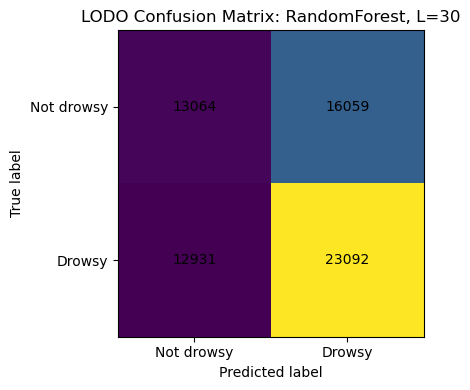

In [17]:
# Select best configuration by mean F1 for drowsy class, then AUROC
best_row = all_fold_results.groupby(["seq_len", "model"])[["f1_drowsy", "auroc", "accuracy"]].mean().sort_values(["f1_drowsy", "auroc"], ascending=False).head(1)
print("Best configuration:")
display(best_row)

best_seq_len, best_model = best_row.index[0]
print("Best seq_len:", best_seq_len, "Best model:", best_model)

# Combine predictions from matching model
pred_frames = []
if 'preds_df' in globals() and len(preds_df): pred_frames.append(preds_df)
if 'deep_preds_df' in globals() and len(deep_preds_df): pred_frames.append(deep_preds_df)
all_preds = pd.concat(pred_frames, ignore_index=True)
all_preds.to_csv(OUT_DIR / "all_lodo_predictions.csv", index=False)

best_preds = all_preds[(all_preds["seq_len"] == best_seq_len) & (all_preds["model"] == best_model)]
cm = confusion_matrix(best_preds["y_true"], best_preds["y_pred"])
print(cm)
print(classification_report(best_preds["y_true"], best_preds["y_pred"], target_names=["Not drowsy", "Drowsy"], zero_division=0))
save_confusion_matrix(cm, f"LODO Confusion Matrix: {best_model}, L={best_seq_len}", OUT_DIR / "best_confusion_matrix.png")

## 11. Manuscript-ready interpretation notes

After running all cells, use the saved files in `results_clean` for the Results section:

- `summary_results.csv`: main comparison table.
- `all_lodo_fold_results.csv`: fold-level results.
- `all_lodo_predictions.csv`: all predictions.
- `best_confusion_matrix.png`: confusion matrix for the best model.

The manuscript should only claim models and protocols that appear in these outputs.